In [1]:
%load_ext dotenv
%dotenv
%load_ext mypy_ipython

In [2]:
from langgraph.graph import START, END, StateGraph
from typing_extensions import TypedDict
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.messages import HumanMessage, BaseMessage 
from langchain_core.runnables import Runnable
from collections.abc import Sequence

In [3]:
class State(TypedDict):
    messages: Sequence[BaseMessage]   

In [4]:
state = State(messages = [HumanMessage("Could you tell me a grook by Piet Hein?")])

In [5]:
state

{'messages': [HumanMessage(content='Could you tell me a grook by Piet Hein?', additional_kwargs={}, response_metadata={})]}

In [6]:
state["messages"][0].pretty_print()

================================ Human Message =================================

Could you tell me a grook by Piet Hein?


In [7]:
chat = ChatOpenAI(model = "gpt-4o", seed = 365, temperature = 0, max_completion_tokens = 100)

In [8]:
response = chat.invoke(state["messages"])

In [10]:
response.pretty_print()

================================== Ai Message ==================================

Certainly! Here is one of Piet Hein's well-known grooks:

**The Road to Wisdom**

The road to wisdom?—Well, it's plain
and simple to express:
Err
and err
and err again,
but less
and less
and less.

Piet Hein's grooks are known for their brevity and depth, often capturing profound truths in just a few lines.


In [11]:
def chatbot(state: State) -> State:
    
    print(f"\n-------> ENTERING chatbot:")
        
    response = chat.invoke(state["messages"])
    response.pretty_print()

    return State(messages = [response])

In [12]:
chatbot(state)


-------> ENTERING chatbot:
================================== Ai Message ==================================

Certainly! Here's a well-known grook by Piet Hein:

**"The Road to Wisdom"**

The road to wisdom?—Well, it's plain
and simple to express:
Err
and err
and err again,
but less
and less
and less.

Piet Hein's grooks are known for their brevity and depth, often combining humor with philosophical insights.


{'messages': [AIMessage(content='Certainly! Here\'s a well-known grook by Piet Hein:\n\n**"The Road to Wisdom"**\n\nThe road to wisdom?—Well, it\'s plain\nand simple to express:\nErr\nand err\nand err again,\nbut less\nand less\nand less.\n\nPiet Hein\'s grooks are known for their brevity and depth, often combining humor with philosophical insights.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 76, 'prompt_tokens': 18, 'total_tokens': 94, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_e8cb92c267', 'id': 'chatcmpl-DSN6iTXXyUO0PiDm3SKeoK5JWyqQ4', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d6d3f-9c7a-7e32-b576-2f147b781106-0', tool_calls=[], invalid_tool_

In [14]:
graph = StateGraph(State)

In [15]:
graph.add_node("chatbot", chatbot)

In [17]:
graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)

In [18]:
graph_compiled = graph.compile()

In [22]:
isinstance(graph, Runnable)

False

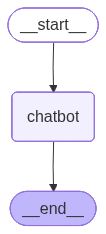

In [23]:
graph_compiled